# Run Parcels — windowed array (PR #2671), 1M particles

Advect 1,000,000 surface particles using the windowed-array `FieldSet` from
parcels PR [#2671](https://github.com/parcels-code/Parcels/pull/2671) via
`fieldset.to_windowed_arrays(...)`. Kernel:
`Pixi: cmems_global (pr2671-windowed-array)`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import parcels
import xarray as xr

/tmp/ipykernel_1692240/1165412407.py:5: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


In [2]:
data_dir = "/work/bk1450/b381575/elphe-hackathon_data"

In [3]:
print(parcels.__version__)

3.1.3.dev2088


In [4]:
ds_fields = xr.open_zarr(Path(data_dir) / "cmems_uovo_2001.zarr")
ds_fields

<xarray.Dataset> Size: 35GB
Dimensions:    (time: 10, depth: 50, latitude: 2041, longitude: 4320)
Coordinates:
  * time       (time) datetime64[ns] 80B 2001-01-01 2001-01-02 ... 2001-01-10
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 8kB -80.0 -79.92 -79.83 ... 89.83 89.92 90.0
  * longitude  (longitude) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9
Data variables:
    uo         (time, depth, latitude, longitude) float32 18GB dask.array<chunksize=(10, 2, 512, 2048), meta=np.ndarray>
    vo         (time, depth, latitude, longitude) float32 18GB dask.array<chunksize=(10, 2, 512, 2048), meta=np.ndarray>
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.4.1

In [5]:
fields = {"U": ds_fields["uo"], "V": ds_fields["vo"]}
ds_fset = parcels.convert.copernicusmarine_to_sgrid(fields=fields)
ds_fset = ds_fset.fillna(0.0)
ds_fset = ds_fset.isel(depth=slice(0, 2))
fieldset = parcels.FieldSet.from_sgrid_conventions(ds_fset)
print(fieldset)

<FieldSet>
    fields:
        <Field 'U'>
            Parcels attributes:
                name            : 'U'
                interp_method   : <function XLinear at 0x1553bbdf3950>
                time_interval   : TimeInterval(left=np.datetime64('2001-01-01T00:00:00.000000000'), right=np.datetime64('2001-01-10T00:00:00.000000000'))
                igrid           : -1
            DataArray:
                <xarray.DataArray 'U' (time: 10, depth: 2, lat: 2041, lon: 4320)> Size: 705MB
                dask.array<chunksize=(10, 2, 512, 2048), meta=np.ndarray>
                Coordinates:
                  * time     (time) datetime64[ns] 80B 2001-01-01 2001-01-02 ... 2001-01-10
                  * depth    (depth) float32 8B 0.494 1.541
                  * lat      (lat) float32 8kB -80.0 -79.92 -79.83 -79.75 ... 89.83 89.92 90.0
                  * lon      (lon) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.8 179.9
                Attributes:
                    cell_methods:   are

In [6]:
n_particles = 1_000_000

lon = np.random.uniform(-80, 20, size=(n_particles,))
lat = np.random.uniform(-35, 40, size=(n_particles,))
z = np.full_like(lon, ds_fields.depth.values[0])  # surface
time = np.array(
    [ds_fields.time.values[0] for _ in range(n_particles)]
)  # initial time of the input data

pset = parcels.ParticleSet(
    fieldset=fieldset.to_windowed_arrays(max_levels=2),
    pclass=parcels.Particle,
    time=time,
    z=z,
    lat=lat,
    lon=lon,
)
print(pset)

<ParticleSet>
    Number of particles: 1000000
    Particles:
        P[0]: time=0.000000, z=0.494025, lat=38.650867, lon=11.062104, particle_id=0.000000
        P[1]: time=0.000000, z=0.494025, lat=-33.185188, lon=-40.768684, particle_id=1.000000
        P[2]: time=0.000000, z=0.494025, lat=-26.781210, lon=-74.944595, particle_id=2.000000
        P[3]: time=0.000000, z=0.494025, lat=-0.354247, lon=-62.992508, particle_id=3.000000
        P[4]: time=0.000000, z=0.494025, lat=-22.129801, lon=-32.422543, particle_id=4.000000
        P[5]: time=0.000000, z=0.494025, lat=29.367659, lon=-17.203485, particle_id=5.000000
        P[6]: time=0.000000, z=0.494025, lat=25.250608, lon=-70.508644, particle_id=6.000000
        ...
        P[999999]: time=0.000000, z=0.494025, lat=26.523052, lon=7.509906, particle_id=999999.000000
    Pclass:
        Variable(name='lon', dtype=dtype('float32'), initial=0, to_write=True, attrs={'standard_name': 'longitude', 'units': 'degrees_east', 'axis': 'X'})
     

In [7]:
kernels = [parcels.kernels.AdvectionRK4]

In [8]:
output_file = parcels.ParticleFile(
    "02b_trajectories.parquet", outputdt=np.timedelta64(6, "h"), mode="w"
)

In [9]:
pset.execute(
    kernels,
    runtime=np.timedelta64(9, "D"),
    dt=np.timedelta64(2, "h"),
    output_file=output_file,
)

INFO: Output files are stored in 02b_trajectories.parquet
Integration time: 2001-01-09T18:00:00 100%|██████████| [09:00<00:00, 1438.74it/s]


In [10]:
df = parcels.read_particlefile("02b_trajectories.parquet")
df

lon,lat,z,time,particle_id
f32,f32,f32,datetime[ns],i64
11.062104,38.650867,0.494025,2001-01-01 00:00:00,0
-40.768684,-33.185188,0.494025,2001-01-01 00:00:00,1
-74.944595,-26.78121,0.494025,2001-01-01 00:00:00,2
-62.992508,-0.354247,0.494025,2001-01-01 00:00:00,3
-32.422543,-22.129801,0.494025,2001-01-01 00:00:00,4
…,…,…,…,…
-6.312431,38.756596,0.494025,2001-01-10 00:00:00,999995
-14.113311,-3.320713,0.494025,2001-01-10 00:00:00,999996
-55.873745,10.48694,0.494025,2001-01-10 00:00:00,999997


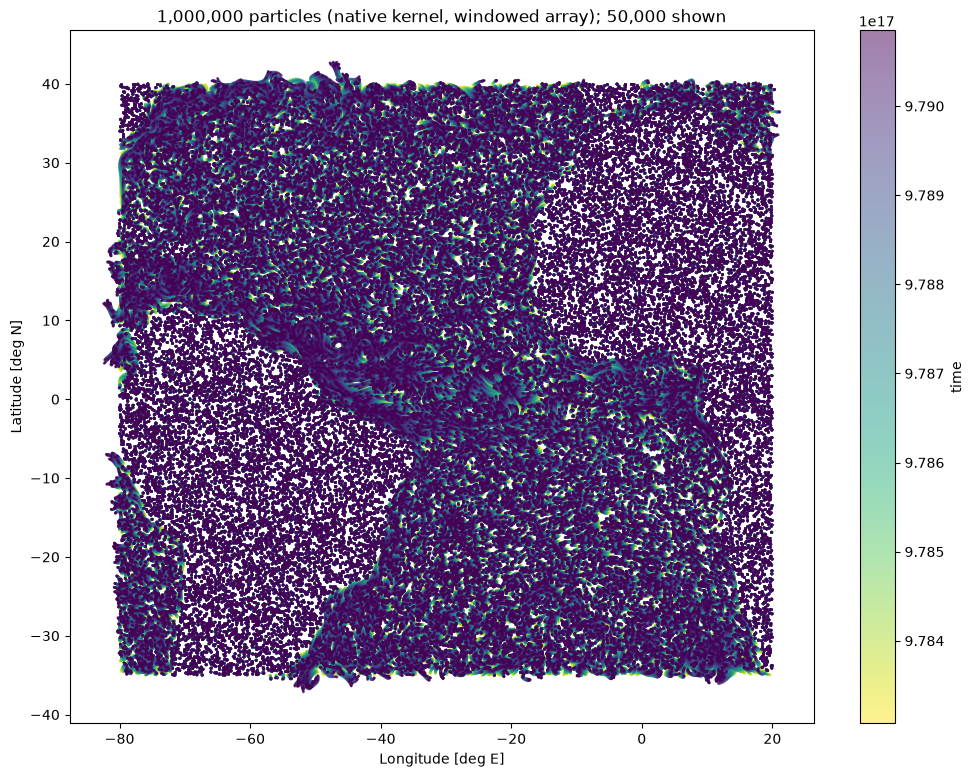

In [11]:
n_plot = min(50_000, n_particles)
rng = np.random.default_rng(0)
plot_ids = rng.choice(n_particles, size=n_plot, replace=False)
pdf = df.to_pandas()
_df = pdf[np.isin(pdf["particle_id"].to_numpy(), plot_ids)]

fig, ax = plt.subplots(figsize=(12, 9))
scatter = ax.scatter(
    _df["lon"], _df["lat"], c=_df["time"], s=1, alpha=0.5, cmap="viridis_r"
)
ax.set_xlabel("Longitude [deg E]")
ax.set_ylabel("Latitude [deg N]")
ax.set_title(
    f"{n_particles:,} particles (native kernel, windowed array); {n_plot:,} shown"
)
fig.colorbar(scatter, ax=ax, label="time")
plt.show()